## KI in Spielen
(Brett)spiele egnen sich besonders als Beispiele für KI, da sie einfache zustände und klare Aktionen haben. Sie sind als Suchproblem Realisierbar. Allerdings werden diese Suchprobleme in der Praxis riesig (eg: Schach).


## KI ins Spielen: Minimax
Zwei Spieler: Min und Max
Max versucht das Spiel zu gewinnen (optimal), Min versucht das Spiel (optimal) zu verlieren.

Spielergebniss: Max gewinnt => +1, Min gewinnt => -1.



    def Max-Value(state):
        if Terminal-Test(state): return Utility(state)

        v = -INF
        for (a, s) in Successors(state):
            v = MAX(v, Min-Value(s))
        return v

    def Min-Value(state):
        if Terminal-Test(state): return Utility(state)

        v = +INF
        for (a, s) in Successors(state):
            v = MIN(v, Max-Value(s))
        return v

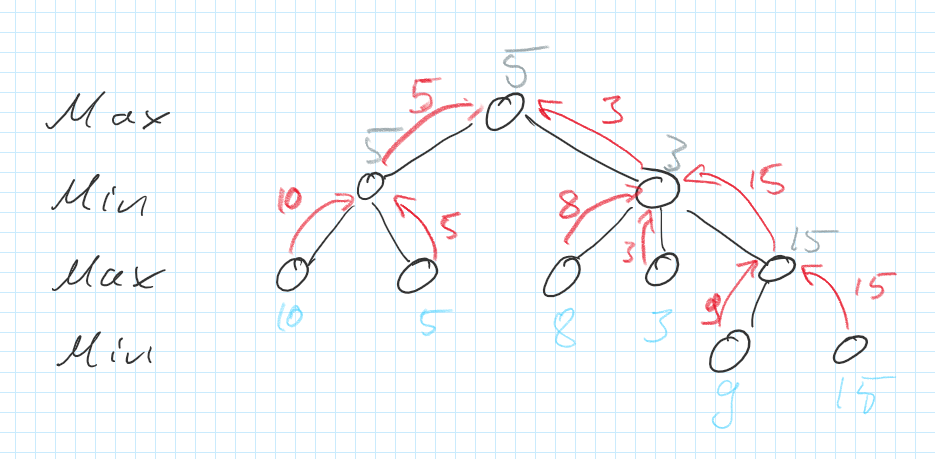

## KI in Spielen: Heuristik
Anstatt die Qualität eines Branches mit einer Utility function vollständig zu berechnen, verwendet man eine Eval funktion, welche die Qualität eines BRanches schätzt. Sieh geht dabei nur bedingt Tief in den Baum.


## Alpha-Beta-Pruning
Standard Minimax, nur das ein alpha und beta parameter mitgeführt wird. Alpha für den bisher bekannten MAX Wert, beta den Min Wert. 

Findet Max-Value() einen Sub-Branch der Größer ist als der aktuelle beta kann er abbrechen und den gefundenen Wert zurückgeben. => Egal wie groß der Wert in den restlichen Branches noch wird. Die Vorherige Min-Value() wird sowieso den Beta Wert nehmen.

Umgekehrt natürlich für Min-Value()


# Aufgabe 1

## 1
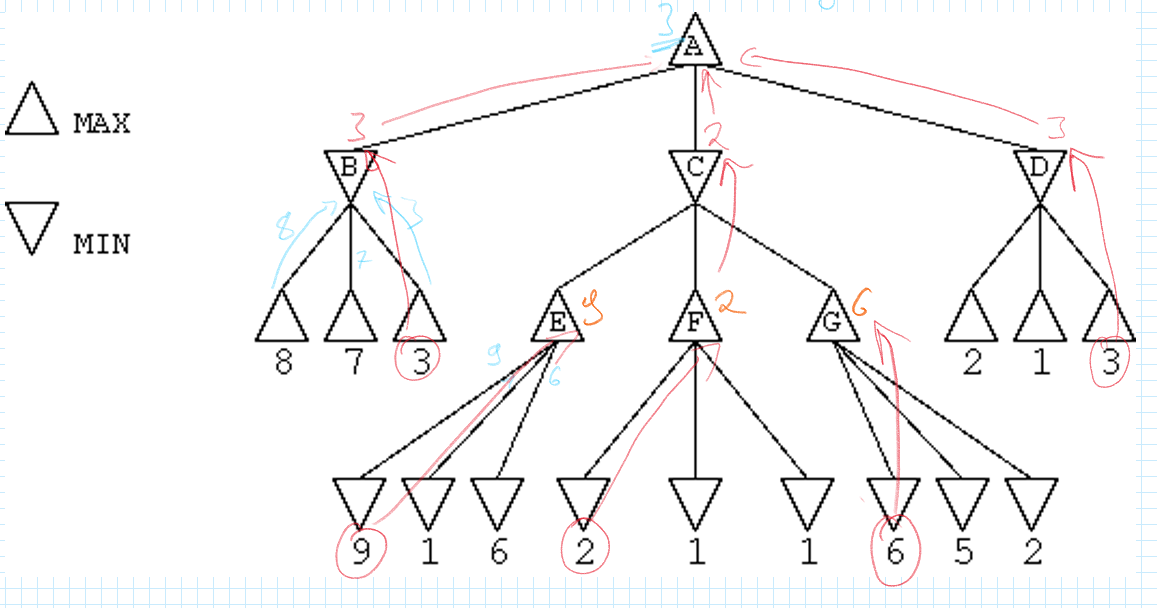

## 2
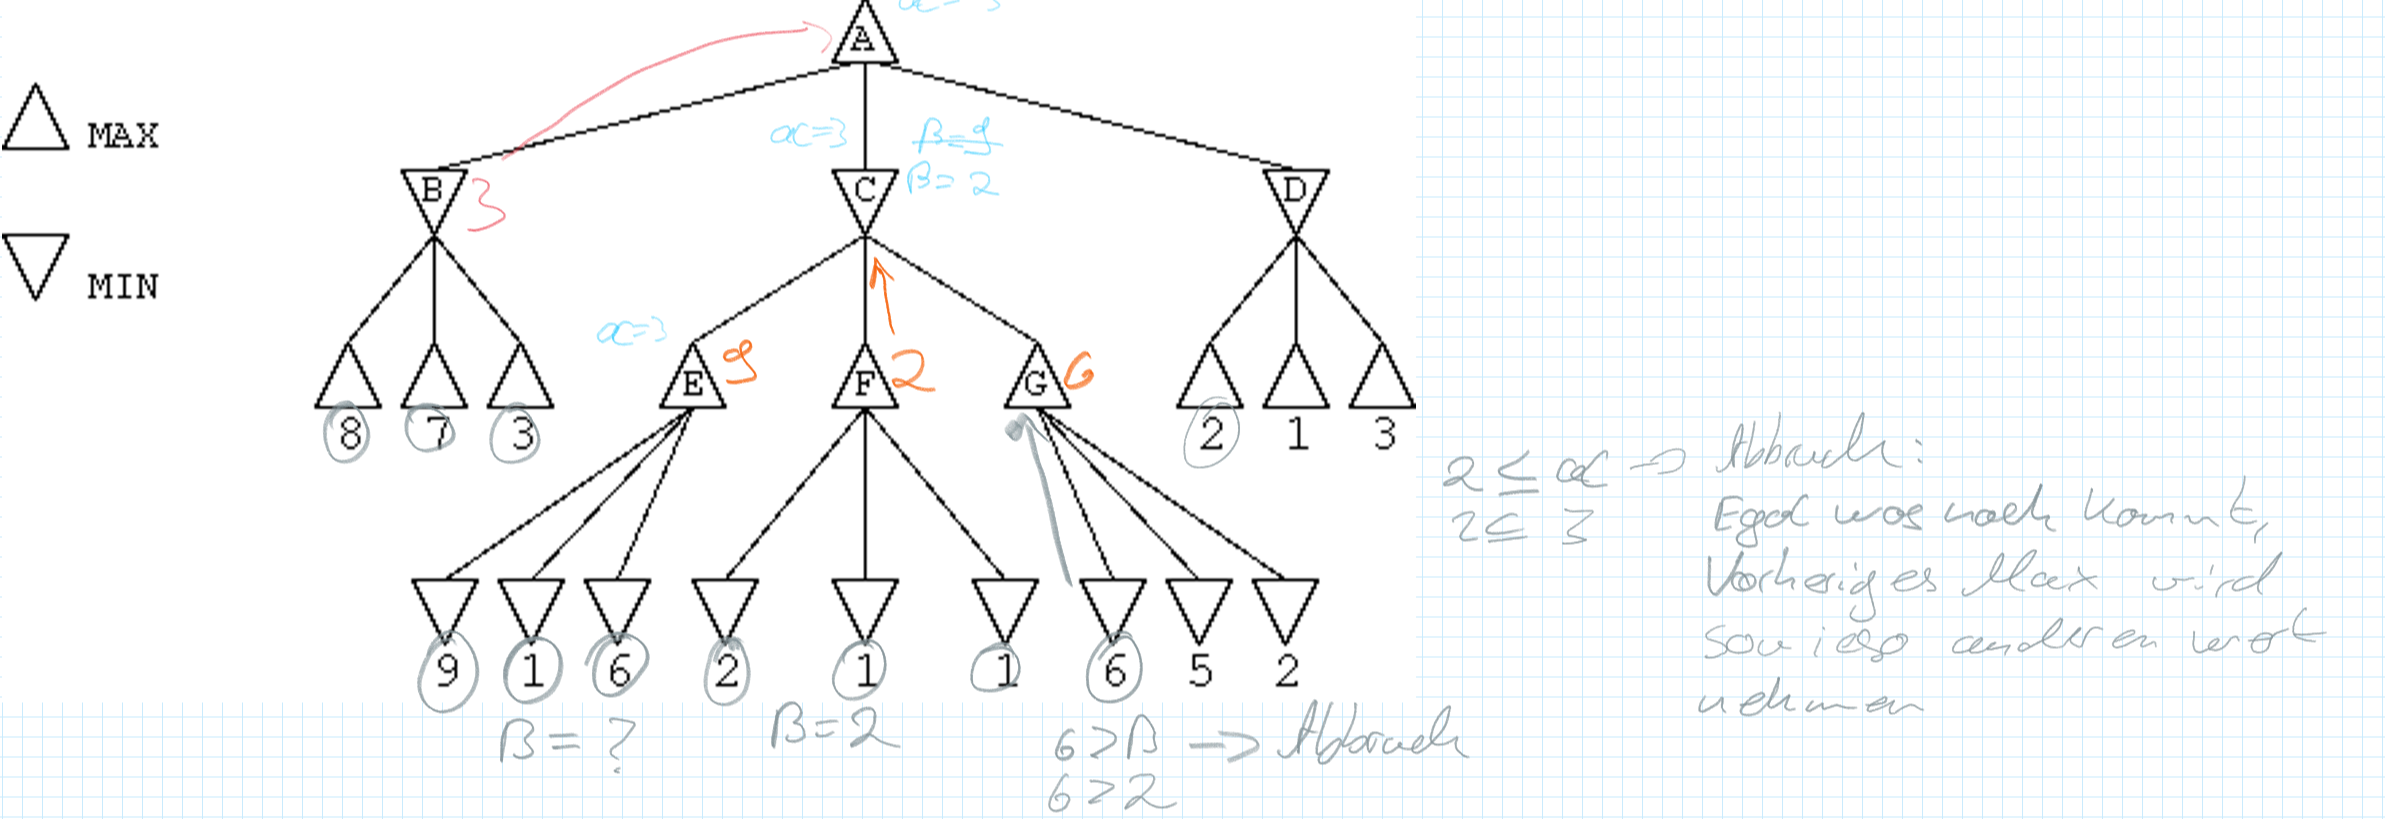

## 3
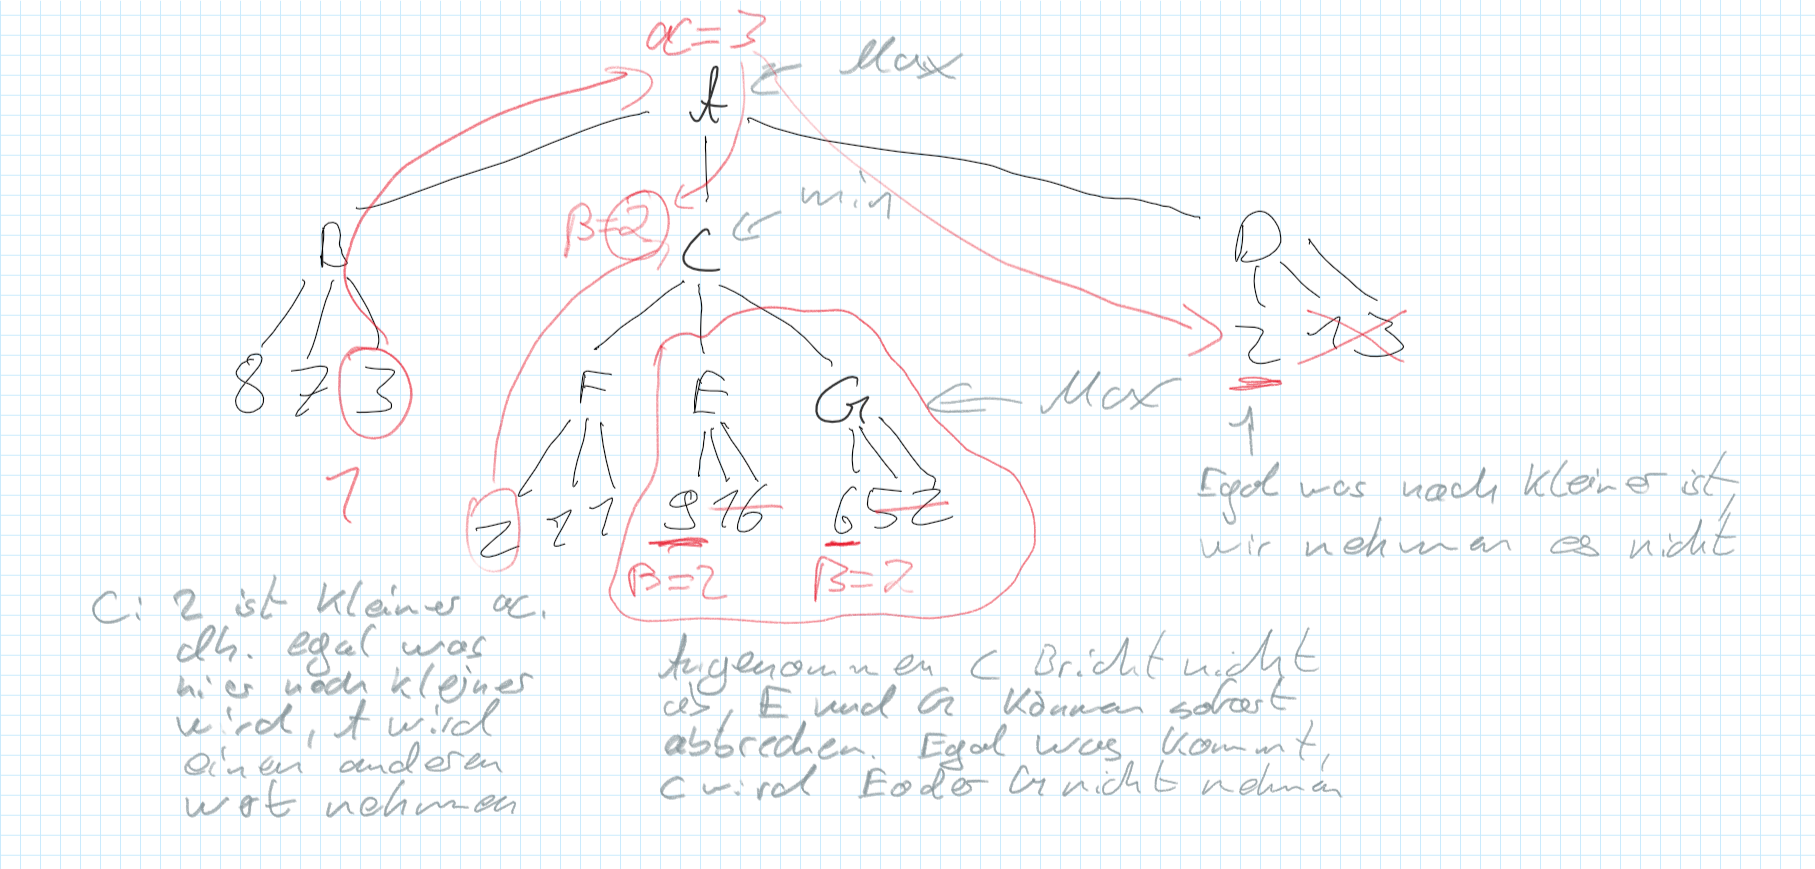

# Aufgabe 2

Tic-Tac-Toe

The TiTacToeField contains the state of a play field.
It provides the following:
 * GetField(int, int) -> to get the state of a field
 * GetState() -> if the filed is in a win / los state
 * Play() -> do a play. Returns a new Field with the given play made, and the active player swapped
 * GetEmptyField() -> Get the remaining empty field

In [23]:

public enum Player {
    PlayerA, 
    PlayerB,
    Unknown
}


class TicTakToeField {
    private readonly (int X, int Y) _position;
    private readonly int _player;
    private readonly TicTakToeField? _parent;
    private readonly int _count;

    public TicTakToeField() {
        _position = (-1, -1);
        _player = -1;
        _count = 0;
    }

    public TicTakToeField(TicTakToeField parent, (int, int) position, int player, int count) {
        _parent = parent;
        _position = position;
        _player = player;
        _count = count;
    }

    public TicTakToeField Play((int, int) position) => 
        new TicTakToeField(this, position, _player * -1, _count + 1);
    
    public TicTakToeField Play(int x, int y) => Play((x, y));


    public int Number => _count;

    public int GetField((int, int) position) {
        if (position == _position)
            return _player;
        
        return _parent?.GetField(position) ?? 0;
    }

    public int GetFieldOrder((int, int) position) {
        if (position == _position)
            return _count;
        
        return _parent?.GetFieldOrder(position) ?? 0;
    }

    public int GetState() {
        var map = GetMap();

        if (CheckPlayer(1))
            return 1;
        if (CheckPlayer(-1))
            return -1;
        return 0;

        bool CheckPlayer(int player) {
            if (map.Any(x => x.All(y => y == player)))
                return true;

            for (int i = 0; i < 3; i++) {
                if (map[0][i] == player 
                    && map[1][i] == player 
                    && map[2][i] == player)
                    return true;
            }

            if (map[0][0] == player && map[1][1] == player && map[2][2] == player)
                return true;

            if (map[0][2] == player && map[1][1] == player && map[2][0] == player)
                return true;

            return false;
        }
    }

    public int[][] GetMap() {
        return Enumerable.Range(0,3)
        .Select(i => Enumerable.Range(0,3)
            .Select(j => GetField((i, j)))
            .ToArray())
        .ToArray();
    }
    
    public int[][] GetMapOrder() {
        return Enumerable.Range(0,3)
        .Select(i => Enumerable.Range(0,3)
            .Select(j => GetFieldOrder((i, j)))
            .ToArray())
        .ToArray();
    }

    public IEnumerable<(int X, int Y)> GetEmptyFields() {
        var map = GetMap();
        for (int i = 0; i < map.Length; i++) {
            for (int j = 0; j < map[i].Length; j++) {
                if (map[i][j] == 0)
                    yield return (i, j);
            }
        }
    }

    public void Draw() {
        Console.WriteLine(string.Join(
            "\n", 
            GetMap().Select(x => 
                string.Join("|", x.Select(y => y switch {
                    1 => "x",
                    -1 => "o",
                    _ => " "
                }))

            )));
    }
    
    public void DrawOrder() {
        Console.WriteLine(string.Join(
            "\n", 
            GetMapOrder().Select(x => 
                string.Join("|", x.Select(y => y switch {
                    0 => " ",
                    _ => $"{y}"
                }))
            )));
        // foreach (var r in GetMap()) {
        //     foreach (var c in r) {
        //         c switch {
        //             1 => "x",
        //             -1 => "o",
        //             _ => " "
        //         };
        //     }
        //     Console.WriteLine();
        // }
    }
}



In [24]:
var end = new TicTakToeField().Play((1, 1)).Play((0, 0)).Play((0, 1)).Play((1, 0));
end.Draw();
end.GetState()

o|x| 
o|x| 
 | | 


0

PlayTree lazily generates every possible play

In [25]:

class PlayTree {
    private readonly TicTakToeField _playField;

    public PlayTree(TicTakToeField playField) {
        _playField = playField;
    }

    public TicTakToeField Field => _playField;

    // Get number (wining, loosing) games
    public int Evaluate() {
        if (_playField.GetState() is { } state && state != 0)
            return state;
        
        return GetOptions().Sum(x => x.Evaluate());
    }

    public (int A, int B) EvaluateBoth() {
        if (_playField.GetState() is { } state && state != 0) {
            if (state > 0)
                return (1, 0);
            else 
                return (0, 1);
        }
        
        
        return GetOptions()
            .Select(x => x.EvaluateBoth())
            .Aggregate((0, 0), (a, b) => (a.Item1 + b.Item1, a.Item2 + b.Item2));
    }

    public IEnumerable<PlayTree> GetOptions() => 
        _playField.GetEmptyFields()
            .Select(x => new PlayTree(_playField.Play(x)));
}

In [26]:
static void Info(this PlayTree tree) 
{
    tree.Field.Draw();
    Console.WriteLine();
    tree.Field.DrawOrder();

    Console.WriteLine($"State: {tree.Field.GetState()}");
}

In [27]:
var t = new PlayTree(new TicTakToeField());

while (t.GetOptions().FirstOrDefault() is {} next) {
    t = next;
    Console.Write($"{t.Evaluate()}, ");

    if (t.Field.GetState() != 0)
        break;
}

Console.WriteLine();

t.Field.Draw();
t.Field.GetState()

6756, 1292, 124, 38, 14, 4, 1, 
x|o|x
o|x|o
x| | 


1

In [28]:
var t = new PlayTree(new TicTakToeField());

// Print the number of (win, lose) for every possible initial play
foreach (var o in t.GetOptions()) {
    Console.Write($"{o.EvaluateBoth()}, ");
}

(14652, 7896), (14232, 10176), (14652, 7896), (14232, 10176), (15648, 5616), (14232, 10176), (14652, 7896), (14232, 10176), (14652, 7896), 

## Simple
This one only checks if the branch is a winning or loosing branch

In [29]:
// Shuffles the possible plays so different games are played each time
public static Span<T> Shuffle<T>(this IEnumerable<T> collection) {
    var c = collection.ToArray();
    Random.Shared.Shuffle(c);
    return c;
}


class Minimax {

    /// Number of nodes visited
    public int NodeCount {get;set;}

    public int Utility(PlayTree state) {
        return state.Evaluate();
    }

    public bool TerminalState(PlayTree state) {
        return state.Field.GetState() is { } s && s != 0 
            || !state.GetOptions().Any();
    }

    public (PlayTree, int) Max(PlayTree state) {
        NodeCount++;
        if (TerminalState(state))
            return (state, Utility(state));

        PlayTree s = null!;
        int v = int.MinValue;
        foreach (var sub in state.GetOptions().Shuffle()) {
            var (sm, vm) = Min(sub);
            if (vm > v) {
                v = vm;
                s = sm;
            }
        }
        return (s, v);
    }

    public (PlayTree, int) Min(PlayTree state) {
        NodeCount++;
        if (TerminalState(state))
            return (state, Utility(state));

        PlayTree s = null!;
        int v = int.MaxValue;
        // shuffle generates different plays each run
        foreach (var sub in state.GetOptions().Shuffle()) {
            var (sm, vm) = Max(sub);
            if (vm < v) {
                v = vm;
                s = sm;
            }
        }
        return (s, v);
    }

}

In [39]:
var minimax = new Minimax();
var (s, w) = minimax.Max(new PlayTree(new TicTakToeField()));

s.Field.Draw();

Console.WriteLine($"State: {s.Field.GetState()}");
Console.WriteLine($"Node count: {minimax.NodeCount}");


x|o|o
o|x|x
x|x|o
State: 0
Node count: 549946


In [31]:

// Instead of checking if the Branch can succeed (1) or fail (-1) and returning that,
// this one sums the possible end states of the branches. Wins add to the sum Losses subtract -> the higher
// the sum the mor options to win are in a branch
class Minimax2 {

    public int NodeCount {get;set;}

    public int Utility(PlayTree state) {
        return state.Evaluate();
    }

    public bool TerminalState(PlayTree state) {
        return state.Field.GetState() is { } s && s != 0 
            || !state.GetOptions().Any();
    }

    // private Span<PlayTree> GetTrees(PlayTree state) => state.GetOptions().Shuffle();
    private IEnumerable<PlayTree> GetTrees(PlayTree state) => state.GetOptions();

    public (PlayTree, int) Max(PlayTree state) {
        NodeCount++;
        if (TerminalState(state))
            return (state, Utility(state));

        PlayTree s = null!;
        int v = int.MinValue;
        var branchSum = 0;
        foreach (var sub in GetTrees(state)) {
            var (sm, vm) = Min(sub);
            if (vm > v) {
                v = vm;
                s = sm;
            }
            branchSum += vm;
        }
        // return (s, v);
        return (s, branchSum);
    }

    public (PlayTree, int) Min(PlayTree state) {
        NodeCount++;
        if (TerminalState(state))
            return (state, Utility(state));

        PlayTree s = null!;
        int v = int.MaxValue;
        var branchSum = 0;

        // shuffle generates different plays each run
        foreach (var sub in GetTrees(state)) {
            var (sm, vm) = Max(sub);
            if (vm < v) {
                v = vm;
                s = sm;
            }
            branchSum += vm;
        }
        // return (s, v);
        return (s, branchSum);
    }

}

In [32]:
var minimax = new Minimax2();
var (s, w) = minimax.Max(new PlayTree(new TicTakToeField()));

s.Field.Draw();

// s.Field.GetState()
minimax.NodeCount

o|x| 
x|x|x
o|o| 


549946

## Alpha-Beta

In [33]:
class AlphaBeta {

    public int NodeCount {get;set;}

    public int Utility(PlayTree state) {
        return state.Evaluate();
    }

    public bool TerminalState(PlayTree state) {
        return state.Field.GetState() is { } s && s != 0 
            || !state.GetOptions().Any();
    }

    // private Span<PlayTree> GetTrees(PlayTree state) => state.GetOptions().Shuffle();
    private IEnumerable<PlayTree> GetTrees(PlayTree state) => state.GetOptions();

    public (PlayTree, int) Max(PlayTree state, int alpha, int beta) {
        NodeCount++;
        if (TerminalState(state))
            return (state, Utility(state));

        PlayTree s = null!;
        int v = int.MinValue;
        foreach (var sub in GetTrees(state)) {
            var (sm, vm) = Min(sub, alpha, beta);
            if (vm > v) {
                v = vm;
                s = sm;
            }

            // check if v is larger that beta. In that case there is no reason to check more nodes
            if (v >= beta)
                return (s, v);

            // alpha for all other children is the biggest value
            alpha = Math.Max(alpha, v);

            // branchSum += vm;
        }
        // return (s, v);
        return (s, v);
    }

    public (PlayTree, int) Min(PlayTree state, int alpha, int beta) {
        NodeCount++;
        if (TerminalState(state))
            return (state, Utility(state));

        PlayTree s = null!;
        int v = int.MaxValue;

        // shuffle generates different plays each run
        foreach (var sub in GetTrees(state)) {
            var (sm, vm) = Max(sub, alpha, beta);
            if (vm < v) {
                v = vm;
                s = sm;
            }

            if (v <= beta)
                return (s, v);
            
            beta = Math.Min(v, beta);

        }
        // return (s, v);
        return (s, v);
    }

}


var alphaBeta = new AlphaBeta();
var (s, w) = alphaBeta.Max(new PlayTree(new TicTakToeField()), int.MinValue, int.MaxValue);
s.Info();
Console.WriteLine($"Node count: {alphaBeta.NodeCount}");

x|o|x
o|x|o
x| | 

1|2|3
4|5|6
7| | 
State: 1
Node count: 1850


**AlphaBeta visits significantly fewer nodes**

# Aufgabe 3

In [34]:
class MinimaxCombined {

    public int NodeCount {get;set;}

    public int Utility(PlayTree state) {
        return state.Evaluate();
    }

    public bool TerminalState(PlayTree state) {
        return state.Field.GetState() is { } s && s != 0 
            || !state.GetOptions().Any();
    }

    // private Span<PlayTree> GetTrees(PlayTree state) => state.GetOptions().Shuffle();
    private IEnumerable<PlayTree> GetChildren(PlayTree state) => state.GetOptions();

    public (PlayTree, int) NegMax(PlayTree state) {
        NodeCount++;
        if (TerminalState(state))
            return (state, Utility(state));

        PlayTree s = null!;
        int v = int.MinValue;
        var branchSum = 0;
        foreach (var sub in GetChildren(state)) {
            var (sm, vm) = NegMax(sub);
            vm *= -1;

            if (vm > v) {
                v = vm;
                s = sm;
            }
            branchSum += vm;
        }
        // return (s, v);
        return (s, branchSum);
    }

}

var minimax = new MinimaxCombined();
var (s, w) = minimax.NegMax(new PlayTree(new TicTakToeField()));

s.Field.Draw();

// s.Field.GetState()
minimax.NodeCount

x|o| 
 |x| 
 |o|x


549946

# Aufgabe 4
Evaluierungsfunktion

In [35]:
class MinimaxEval {

    public int NodeCount {get;set;}

    public int Eval(PlayTree state) {
        
        // anything with 3x in a row returns 1, 3 o returns -1
        // Field already has this check
        var s = state.Field.GetState();
        if (s != 0)
            return s;
        // draw state would have no more free fields
        if (state.Field.GetEmptyFields().Count() == 0) {
            return 0;
        }

        // EVAL: 3X2(s)+X1(s)−(3O2(s)+O1(s))
        var map = state.Field.GetMap();
        return 3 * EvalField(map, 1, 2) + EvalField(map, 1, 1) 
            - (3 * EvalField(map, -1, 2) + EvalField(map, -1, 1));
    }


    private int EvalField(int[][] map, int player, int n) {
        return EvalRows(map, player, n) + EvalColumns(map, player, n) + EvalDiagonals(map, player, n);
    }

    private int EvalRows(int[][] map, int player, int n) {
        int count = 0;
        for (int i = 0; i < 3; i++) {
            if (map[i].Count(x => x == player) == n 
             && map[i].Count(x => x == (player *-1)) == 0)
             count++;
        }
        return count;
    }

    private int EvalColumns(int[][] map, int player, int n) {
        int count = 0;
        for (int i = 0; i < 3; i++) {
            var a = 0;
            var b = 0;
            for (int j = 0; j < 3; j++) {
                if (map[j][i] == player)
                    a++;
                if (map[j][i] == (player *-1))
                    b++;
            }

            if (a == n && b == 0)
                count++;
        }
        return count;
    }

    private int EvalDiagonals(int[][] map, int player, int n) {
        var count = 0;
        {
            var a = 0;
            var b = 0;

            for (int i = 0; i < 3; i++) {
                if (map[i][i] == player)
                    a++;
                else if (map[i][i] == (player * -1))
                    b++;
            }

            if (a == n && b == 0)
            count++;
        }

        {
            var a = 0;
            var b = 0;

            for (int i = 0; i < 3; i++) {
                if (map[i][2 - i] == player)
                    a++;
                else if (map[i][2 - i] == (player * -1))
                    b++;
            }

            if (a == n && b == 0)
            count++;
        }
        return count;
    }


    public bool TerminalState(PlayTree state) {
        return state.Field.GetState() is { } s && s != 0 
            || !state.GetOptions().Any();
    }

    // private Span<PlayTree> GetTrees(PlayTree state) => state.GetOptions().Shuffle();
    private IEnumerable<PlayTree> GetTrees(PlayTree state) => state.GetOptions();

    public (PlayTree, int) Max(PlayTree state) {
        NodeCount++;
        if (TerminalState(state))
            return (state, Eval(state));

        PlayTree s = null!;
        int v = int.MinValue;
        
        foreach (var sub in GetTrees(state)) {
            var (sm, vm) = Min(sub);
            if (vm > v) {
                v = vm;
                s = sm;
            }
        }
        // return (s, v);
        return (s, v);
    }

    public (PlayTree, int) Min(PlayTree state) {
        NodeCount++;
        if (TerminalState(state))
            return (state, Eval(state));

        PlayTree s = null!;
        int v = int.MaxValue;

        // shuffle generates different plays each run
        foreach (var sub in GetTrees(state)) {
            var (sm, vm) = Max(sub);
            if (vm < v) {
                v = vm;
                s = sm;
            }
        }
        // return (s, v);
        return (s, v);
    }

}


MinimaxEval EvaluateField(Func<TicTakToeField, TicTakToeField> builder) {
    var minimaxEval = new MinimaxEval();
    var f = new TicTakToeField();
    f = builder(f);
    var result = minimaxEval.Eval(new PlayTree(f));

    f.Draw();
    Console.WriteLine($"Eval: {result}");

    return minimaxEval;
}

MinimaxEval CreatePlayX(Func<TicTakToeField, TicTakToeField> builder) {
    var minimaxEval = new MinimaxEval();
    var f = new TicTakToeField();
    f = builder(f);
    var (s, w) = minimaxEval.Max(new PlayTree(f));
    s.Info();

    return minimaxEval;
}

In [36]:

var minimaxEval = new MinimaxEval();
var (s, w) = minimaxEval.Max(new PlayTree(new TicTakToeField()));
s.Info();
Console.WriteLine($"Nodes: {minimaxEval.NodeCount}")

x|x|o
o|o|x
x|o|x

1|3|4
6|2|7
5|8|9
State: 0
Nodes: 549946


In [37]:
EvaluateField(f => f.Play(1, 1));
EvaluateField(f => f.Play(1, 1).Play(0, 0).Play(0, 1).Play(1, 0).Play(0, 2));
EvaluateField(f => f.Play(0, 0).Play(2, 2).Play(0, 1).Play(2, 1));

 | | 
 |x| 
 | | 
Eval: 4
o|x|x
o|x| 
 | | 
Eval: 4
x|x| 
 | | 
 |o|o
Eval: 0


In [97]:
EvaluateField(f => f.Play(1, 1).Play(0, 0).Play(2, 1).Play(1, 0).Play(0, 1));
EvaluateField(f => f.Play(1, 1).Play(0, 0).Play(2, 1).Play(1, 0).Play(0, 2).Play(2, 0));
EvaluateField(f => f.Play(1, 1).Play(0, 1).Play(2, 2).Play(0, 0).Play(0, 2).Play(2, 0).Play(1, 0).Play(1, 2).Play(2, 1));

o|x| 
o|x| 
 |x| 
Eval: 1
o| |x
o|x| 
o|x| 
Eval: -1
o|o|x
x|x|o
o|x|x
Eval: 0


Eine Eval funktion ist einfacher als zb. die Anzahl der möglichen gewinn / verloren Spiele für jeden branch zu generieren.

# Aufgabe 5

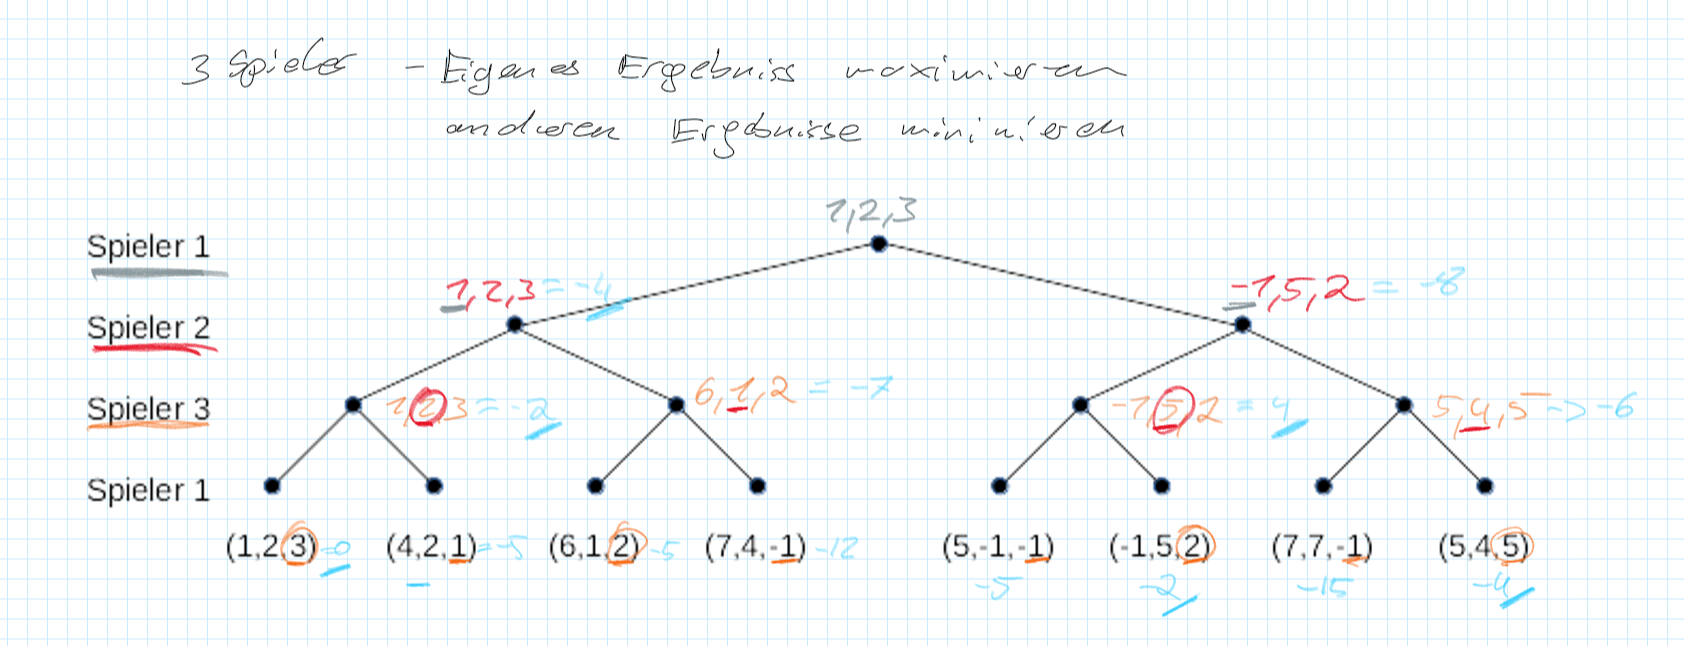

# Post mortem

Jede Person beschreibt in der ILIAS-Abgabe individuell(!) die Bearbeitung des jeweiligen Aufgabenblattes
zurückblickend mit ca. 200 bis 400 Wörtern. Gehen Sie dabei aussagekräftig und nachvollziehbar auf folgende Punkte ein: 
 (a) Zusammenfassung: Was wurde gemacht? 
 (b) Implementierungsdetails: Kurze Beschreibung besonders interessanter Aspekte der Umsetzung. 
 (c) Was war der schwierigste Teil bei der Bearbeitung? Wie haben Sie dieses Problem gelöst? 
 (d) Was haben Sie gelernt oder (besser) verstanden? 
 (e) Team: Mit wem haben Sie zusammengearbeitet? 
 (f) Link zum Repo mit der Lösung 



 * a: Die erste Aufgabe habe ich grafisch gelöst. Ich habe die entsprechenden Aktionen markiert und mit Pfeilen dargestellt um eine klare Übersicht zu bekommen. Für den 3. Punkt habe ich den Baum so rearrangiert, dass der jeweils größte / kleinste wert als erstes Abgerufen wird, damit der Algorithmus möglichst früh abbrechen könnte.
    Für Aufgabe 2 habe ich ein TicTacToe Feld und eine Spielbaum Implementiert. Diese können das von den jeweiligen Implementierungen der Minimax Algorithmen verwendet werden. Dabei Zahlen die Implementierungen die Anzahl der besuchten Nodes für einen späterenn Vergleich.
    Für die letzte Aufgabe hatte ich 2 Ansätze, wobei beiden in dem beispiel zu demselben Ergebnis führen. Im ersten Ansatz nehme ich immer den Branch mit dem, für den Aktuellen Spieler besten Bewertung. Im zweiten Ansatz ziehe ich vorher die Bewertung der anderen beiden Spieler ab.
 * b: Das TicTacToe Spielfeld habe ich als readonly Klasse entworfen. Sie hat zwar eine Play() Methode, jedoch gibt die Methode ein neues Spielfeld zurück, in dem zug getätigt wurde. (Ich habe dabei an ein "ImmutableArray" bzw. daran, wie im funktionalen ein "Append" bewerkstelligt wird, gedacht). Dadurch ist es dem PlayTree einfach möglich, jeden möglichen zug zu tätigen. Der Spielbaum ist "Lazy" implementiert. Er generiert die Unterbäume also nur, wen sie abgerufen werden. Ich habe den Minimax außerdem 2 mal implementiert. Der erste verwendet lediglich die Branch Evaluierung (won, lost, draw). Die zweite Implementierung zählt die Anzahl an möglichen won / lost Zweigen und verwendet dies als Bewertung.
 * c: -
 * d: Ich habe ein tieferes Verständnis für den Minimax und alpha-beta-pruning gewonnen. Außerdem finde ich die Synergie des readonly Spielfeldes mit dem Baum interessant. (Auch wenn es in diesem Fall vermutlich deutlich effizienter wäre, mit einem einfachen integer Wert zu arbeiten, anstatt jedes mal aus einer LinkedList das Spielfeld zusammenzubauen)
 * e: -
 * f: https://github.com/co1inco/IFM_Programieren3/tree/master/KI/4